# Stage 1.2  Image-Based Contrastive Learning

This notebook walks through the image branch of **Unified-DTI**:  
aligning compound Cell Painting profiles (737-dim) with CRISPR knockdown profiles (599-dim) into a shared 512-dim space via InfoNCE loss.

All model code lives in `src/stage1.2_image/model/`. This notebook imports from those files directly.

## Setup

In [1]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src', 'stage1.2_image', 'model'))

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from config import CONFIG
from dataset import DrugTargetDataset
from model import ContrastiveModel
from loss import InfoNCELoss, compute_alignment_metrics
from train import train_epoch, validate

## Configuration

In [12]:
BASE = os.path.join('..', 'src', 'stage1.2_image')

CONFIG['train_csv'] = os.path.join(BASE, 'data', 'train_pairs.csv')
CONFIG['test_csv'] = os.path.join(BASE, 'data', 'test_pairs.csv')
CONFIG['drug_embeds_path'] = os.path.join(BASE, 'embedding', 'All_compound_image.pt')
CONFIG['target_embeds_path'] = os.path.join(BASE, 'embedding', 'All_CRISPR_image.pt')
CONFIG['save_dir'] = os.path.join(BASE, 'model')

## Dataset

Embedding files (`.pt`) must be downloaded from OneDrive and placed in `src/stage1.2_image/embedding/`.

In [8]:
train_dataset = DrugTargetDataset(
    CONFIG['train_csv'],
    CONFIG['drug_embeds_path'],
    CONFIG['target_embeds_path']
)

test_dataset = DrugTargetDataset(
    CONFIG['test_csv'],
    CONFIG['drug_embeds_path'],
    CONFIG['target_embeds_path']
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

Loaded 17999 valid drug-target pairs
Loaded 4500 valid drug-target pairs


## Training

In [9]:
device = CONFIG['device']

sample   = train_dataset[0]
drug_dim = sample['drug'].shape[0]
tgt_dim  = sample['target'].shape[0]
print(f"Drug dim: {drug_dim}, Target dim: {tgt_dim}")

model     = ContrastiveModel(drug_dim, tgt_dim, CONFIG['hidden_dim'], CONFIG['output_dim'], CONFIG['dropout']).to(device)
criterion = InfoNCELoss(temperature=CONFIG['temperature'])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['num_epochs'])

best_val_loss = float('inf')

for epoch in range(CONFIG['num_epochs']):

    print(f"\nEpoch {epoch+1}/{CONFIG['num_epochs']}")

    train_loss, train_metrics = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_metrics   = validate(model, val_loader, criterion, device)
    scheduler.step()

    if epoch % 10 == 0:
        print(f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        print(f"Train Metrics - Pos Sim: {train_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {train_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {train_metrics['gap']:.4f}, ")
        print(f"Val Metrics   - Pos Sim: {val_metrics['pos_sim_mean']:.4f}, "
              f"Neg Sim: {val_metrics['neg_sim_mean']:.4f}, "
              f"Gap: {val_metrics['gap']:.4f}, ")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(CONFIG['save_dir'], 'best_model.pt'))

print(f"\nDone. Best val loss: {best_val_loss:.4f}")

Drug dim: 737, Target dim: 599

Epoch 1/30


Validating: 100%|██████████| 18/18 [00:00<00:00, 91.28it/s]


Train Loss: 5.4898, Val Loss: 5.3600
Train Metrics - Pos Sim: 0.0388, Neg Sim: 0.0300, Gap: 0.0088, 
Val Metrics   - Pos Sim: 0.0593, Neg Sim: 0.0347, Gap: 0.0246, 

Epoch 2/30


Validating: 100%|██████████| 18/18 [00:00<00:00, 93.16it/s]



Epoch 3/30


...


Epoch 29/30


Validating: 100%|██████████| 18/18 [00:00<00:00, 92.87it/s]



Epoch 30/30


Validating: 100%|██████████| 18/18 [00:00<00:00, 93.07it/s]


Done. Best val loss: 3.8124


## Inference

Load the best checkpoint and extract projected embeddings from the test set.

In [10]:
device = 'cpu'

model = ContrastiveModel(drug_dim=737, target_dim=599, hidden_dim=1024, output_dim=512, dropout=0.1)
model.load_state_dict(torch.load(os.path.join(CONFIG['save_dir'], 'best_model.pt'), map_location=device))
model.to(device)
model.eval()

all_drug_embs, all_target_embs = [], []

with torch.no_grad():
    for batch in val_loader:
        drug_emb   = batch['drug'].to(device)
        target_emb = batch['target'].to(device)
        drug_proj, target_proj = model(drug_emb, target_emb)
        all_drug_embs.append(drug_proj.cpu())
        all_target_embs.append(target_proj.cpu())

all_drug_embs   = torch.cat(all_drug_embs,   dim=0)
all_target_embs = torch.cat(all_target_embs, dim=0)

print(f"Drug embeddings:   {all_drug_embs.shape}")
print(f"Target embeddings: {all_target_embs.shape}")

/scratch/slurm-2447629/ipykernel_1054626/1611002201.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(os.path.join(CONFIG['save_dir'], 'be

Drug embeddings:   torch.Size([4500, 512])
Target embeddings: torch.Size([4500, 512])


## Visualization

Cosine similarity distribution of projected compound vs CRISPR embeddings.

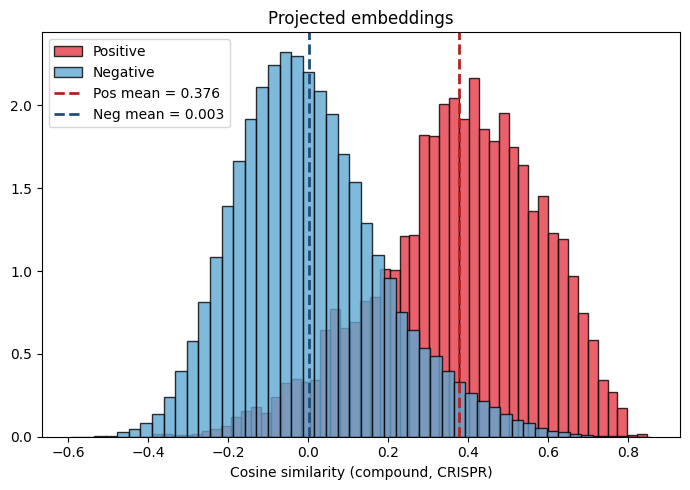

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_similarity(drug_emb, target_emb, title):
    pos_sims   = F.cosine_similarity(drug_emb, target_emb).numpy()
    sim_matrix = (drug_emb @ target_emb.T).numpy()
    neg_sims   = sim_matrix[~np.eye(sim_matrix.shape[0], dtype=bool)].flatten()

    plt.figure(figsize=(7, 5))
    plt.hist(pos_sims, bins=50, color='#e63946', alpha=0.8, label='Positive', density=True, edgecolor='black')
    plt.hist(neg_sims, bins=50, color='#5fa8d3', alpha=0.8, label='Negative', density=True, edgecolor='black')
    plt.axvline(pos_sims.mean(), color='#b22222', linestyle='--', linewidth=2, label=f'Pos mean = {pos_sims.mean():.3f}')
    plt.axvline(neg_sims.mean(), color='#1f4e79', linestyle='--', linewidth=2, label=f'Neg mean = {neg_sims.mean():.3f}')
    plt.xlabel('Cosine similarity (compound, CRISPR)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_similarity(all_drug_embs, all_target_embs, 'Projected embeddings')